In [2]:
import os
import warnings
import itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# list files in the folder
print(os.listdir("/content/drive/MyDrive/DMT_data"))

['test_set_VU_DM.csv', 'training_set_VU_DM.csv', 'DMT_A2.ipynb', 'DMT_data']


In [4]:
!ln -s "/content/drive/MyDrive/DMT_data" /content/DMT_data
# This should now show your data
!ls /content/DMT_data

ln: failed to create symbolic link '/content/DMT_data/DMT_data': File exists
DMT_A2.ipynb  DMT_data	test_set_VU_DM.csv  training_set_VU_DM.csv


Plot style

In [5]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e4e4e4",
    "grid.linewidth":    0.05,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"

In [12]:
data_path = '/content/DMT_data'
train_file = os.path.join(data_path, 'training_set_VU_DM.csv')
test_file = os.path.join(data_path, 'test_set_VU_DM.csv')

train_df = pd.read_csv(train_file)
df = train_df.copy()
display(df.head())
#test = pd.read_csv(test_file)

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [17]:
#df.columns.tolist()
df.isnull().sum()

,0
srch_id,0
date_time,0
site_id,0
visitor_location_country_id,0
visitor_hist_starrating,4706481
visitor_hist_adr_usd,4705359
prop_country_id,0
prop_id,0
prop_starrating,0
prop_review_score,7364


In [18]:
# checking if any rows are droppped due to datetime
initial_count = len(df)
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')
valid_count = df['date_time'].notna().sum()

dropped_rows = initial_count - valid_count
print(f"Total rows dropped: {dropped_rows}")
print(f"Percentage of dataset dropped: {(dropped_rows / initial_count) * 100:.4f}%")

Total rows dropped: 0
Percentage of dataset dropped: 0.0000%


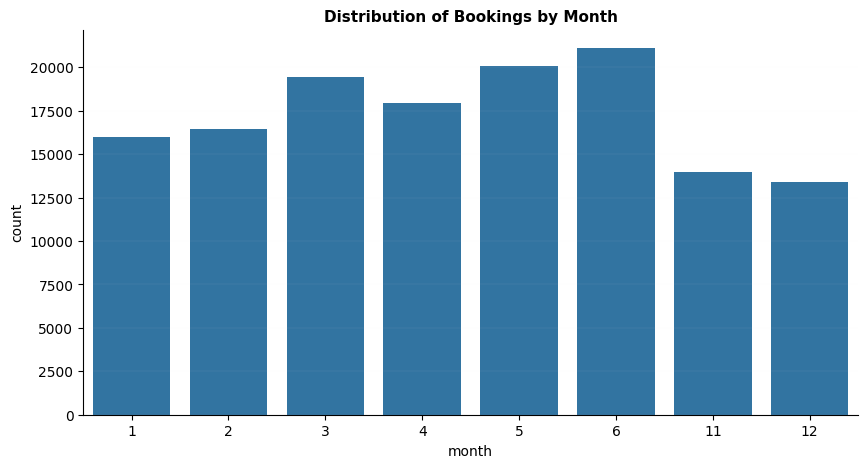

In [19]:
def get_datetime(data):
    data['month'] = data['date_time'].dt.month
    data['day_of_week'] = data['date_time'].dt.dayofweek
    data['hour'] = data['date_time'].dt.hour
    return data

df = get_datetime(df)

# booking distribution by month
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['booking_bool'] == 1], x='month')
plt.title('Distribution of Bookings by Month')
plt.show()

Conversion Rates by Saturday Night Stay:
   srch_saturday_night_bool  click_bool  booking_bool
0                         0    0.044510      0.027004
1                         1    0.044985      0.028809


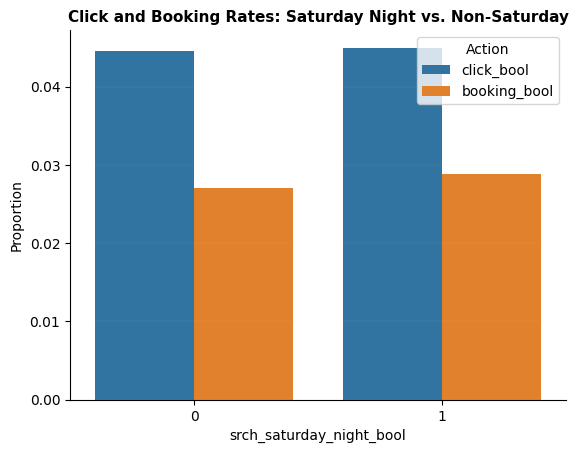

In [20]:
def explore_saturday_stay(data):
    """checking if Saturday night impacts the clicks and bookings"""
    # group by the boolean flag
    stats = data.groupby('srch_saturday_night_bool').agg({
        'click_bool': 'mean',
        'booking_bool': 'mean'
    }).reset_index()

    print("Conversion Rates by Saturday Night Stay:")
    print(stats)

    # plot
    stats_melted = stats.melt(id_vars='srch_saturday_night_bool', value_vars=['click_bool', 'booking_bool'], var_name='Action', value_name='Rate')

    sns.barplot(data=stats_melted, x='srch_saturday_night_bool', y='Rate', hue='Action')
    plt.title('Click and Booking Rates: Saturday Night vs. Non-Saturday')
    plt.ylabel('Proportion')
    plt.show()

explore_saturday_stay(df)

['srch_id',
 'date_time',
 'site_id',
 'visitor_location_country_id',
 'visitor_hist_starrating',
 'visitor_hist_adr_usd',
 'prop_country_id',
 'prop_id',
 'prop_starrating',
 'prop_review_score',
 'prop_brand_bool',
 'prop_location_score1',
 'prop_location_score2',
 'prop_log_historical_price',
 'position',
 'price_usd',
 'promotion_flag',
 'srch_destination_id',
 'srch_length_of_stay',
 'srch_booking_window',
 'srch_adults_count',
 'srch_children_count',
 'srch_room_count',
 'srch_saturday_night_bool',
 'srch_query_affinity_score',
 'orig_destination_distance',
 'random_bool',
 'comp1_rate',
 'comp1_inv',
 'comp1_rate_percent_diff',
 'comp2_rate',
 'comp2_inv',
 'comp2_rate_percent_diff',
 'comp3_rate',
 'comp3_inv',
 'comp3_rate_percent_diff',
 'comp4_rate',
 'comp4_inv',
 'comp4_rate_percent_diff',
 'comp5_rate',
 'comp5_inv',
 'comp5_rate_percent_diff',
 'comp6_rate',
 'comp6_inv',
 'comp6_rate_percent_diff',
 'comp7_rate',
 'comp7_inv',
 'comp7_rate_percent_diff',
 'comp8_rate',


Adding the relevance column to align with the evaluation metric

In [ ]:

# Define conditions
conditions = [
    (df['booking_bool'] == 1),
    (df['click_bool'] == 1)
]

# Define corresponding relevance grades
choices = [5, 1]

# Default to 0 if neither condition is met
df['relevance'] = np.select(conditions, choices, default=0)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/train_correlation_matrix.png'

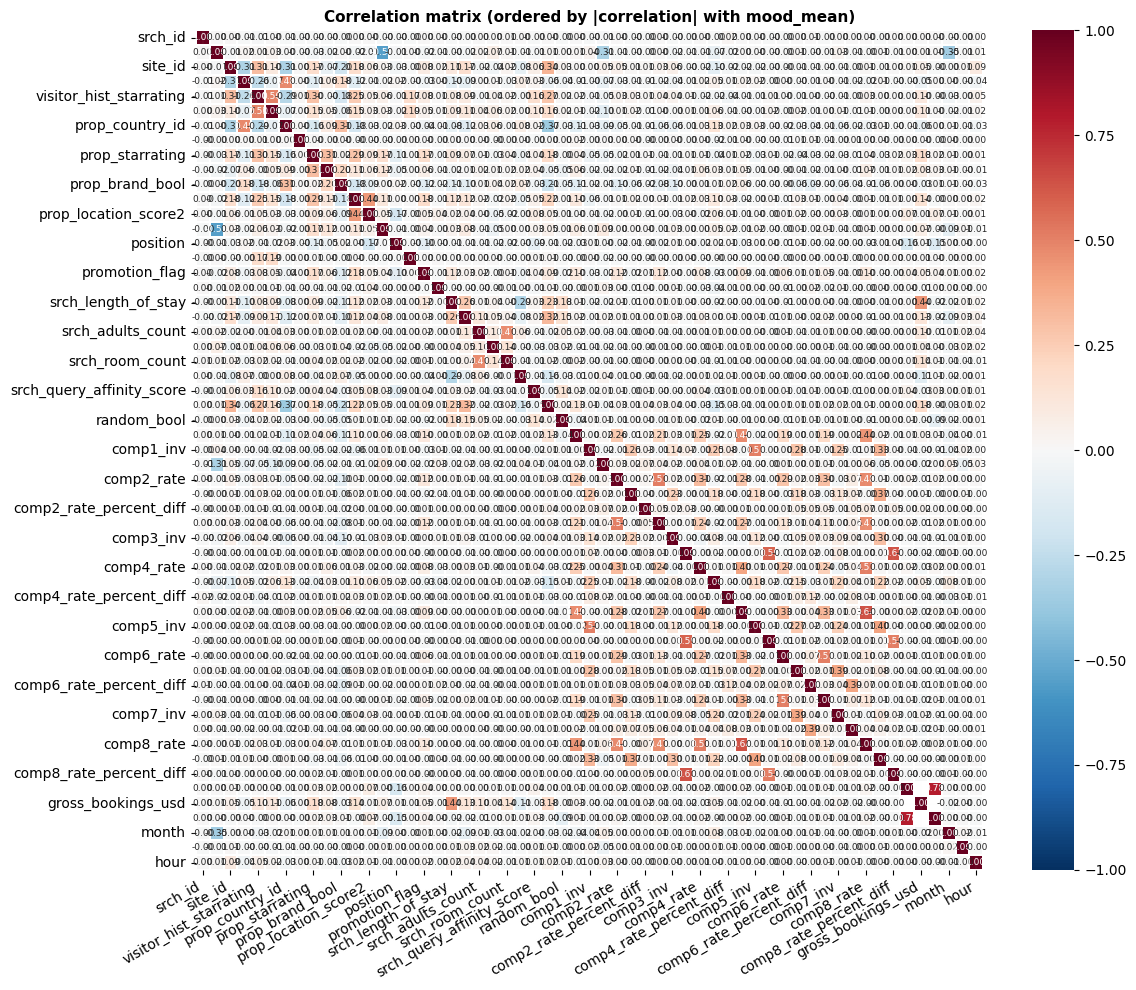

In [21]:
corr  = df.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={"size": 6.5}, ax=ax)
ax.set_title("Correlation matrix (ordered by |correlation| with mood_mean)")
#plt.xticks(fontsize=7,rotation=40)
ax.set_xticklabels(ax.get_xticklabels(),rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figures/train_correlation_matrix.png", dpi=150)
plt.show()

In [ ]:
print("Shape:", df.shape)
print("Unique users:", df["srch_id"].nunique())

Shape: (4958347, 54)
Unique users: 199795


In [ ]:
# per-variable statistics table
grouped = df.groupby("variable")["value"]
total   = grouped.count()
missing = grouped.size() - grouped.count()
missing_pct = (missing / (missing + total) * 100).round(1)

stats = grouped.describe().rename(columns={"50%": "median"})
stats["missing"]   = missing
stats["missing %"] = missing_pct.fillna(100.0)
stats

Read to see what are the options:
https://towardsdatascience.com/a-complete-guide-to-recommender-system-tutorial-with-sklearn-surprise-keras-recommender-5e52e8ceace1/

## K-Nearest Neighbours
https://www.geeksforgeeks.org/machine-learning/recommender-systems-using-knn/


##